# Assignment 16 - SVM, Trees, Ensembles, Validation & Cross Validation

Dataset: Titanic Dataset

Kaggle Link:
https://www.kaggle.com/datasets/yasserh/titanic-dataset

Student:
Abhishek Thakare

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

df = df.drop(columns=["Cabin"])

In [4]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(
    df["Sex"]
)

df["Embarked"] = encoder.fit_transform(
    df["Embarked"]
)

In [5]:
features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked"
]

X = df[features]

y = df["Survived"]

In [6]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

# Task 1 - Support Vector Machine (SVM)

I will compare a Linear kernel and an RBF kernel to understand how different decision boundaries affect performance.

In [8]:
svm_linear = SVC(
    kernel="linear"
)

svm_linear.fit(
    X_train,
    y_train
)

linear_pred = svm_linear.predict(
    X_test
)

linear_acc = accuracy_score(
    y_test,
    linear_pred
)

print(
    "Linear Kernel Accuracy:",
    linear_acc
)

Linear Kernel Accuracy: 0.7821229050279329


In [9]:
svm_rbf = SVC(
    kernel="rbf"
)

svm_rbf.fit(
    X_train,
    y_train
)

rbf_pred = svm_rbf.predict(
    X_test
)

rbf_acc = accuracy_score(
    y_test,
    rbf_pred
)

print(
    "RBF Kernel Accuracy:",
    rbf_acc
)

RBF Kernel Accuracy: 0.8156424581005587


### Observation

The RBF kernel can capture non-linear patterns, while the linear kernel assumes a linear decision boundary.

Comparing their accuracies helps determine whether the Titanic survival problem is linearly separable.

# Task 2 - Decision Tree

In [10]:
tree_small = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_small.fit(
    X_train,
    y_train
)

print(
    "Train Accuracy:",
    tree_small.score(
        X_train,
        y_train
    )
)

print(
    "Test Accuracy:",
    tree_small.score(
        X_test,
        y_test
    )
)

Train Accuracy: 0.8033707865168539
Test Accuracy: 0.7653631284916201


In [11]:
tree_large = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

tree_large.fit(
    X_train,
    y_train
)

print(
    "Train Accuracy:",
    tree_large.score(
        X_train,
        y_train
    )
)

print(
    "Test Accuracy:",
    tree_large.score(
        X_test,
        y_test
    )
)

Train Accuracy: 0.9578651685393258
Test Accuracy: 0.770949720670391


### Observation

A shallow tree may underfit because it cannot learn complex patterns.

A deep tree may overfit because it can memorize training data.

Comparing training and testing accuracy helps identify this behavior.

In [12]:
X_temp, X_test_final, y_temp, y_test_final = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

X_train_final, X_val, y_train_final, y_val = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.25,
        random_state=42
    )
)

In [13]:
validation_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

validation_model.fit(
    X_train_final,
    y_train_final
)

val_pred = validation_model.predict(
    X_val
)

print(
    "Validation Accuracy:",
    accuracy_score(
        y_val,
        val_pred
    )
)

Validation Accuracy: 0.848314606741573


In [14]:
test_pred = validation_model.predict(
    X_test_final
)

print(
    "Test Accuracy:",
    accuracy_score(
        y_test_final,
        test_pred
    )
)

Test Accuracy: 0.8100558659217877


# Task 4 - Cross Validation

In [15]:
cv_scores = cross_val_score(
    DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    X,
    y,
    cv=5
)

print(
    "Cross Validation Scores:"
)

print(cv_scores)

print(
    "Average CV Accuracy:",
    cv_scores.mean()
)

Cross Validation Scores:
[0.75977654 0.8258427  0.81460674 0.78651685 0.84269663]
Average CV Accuracy: 0.8058878915322328


### Observation

Cross-validation is more reliable than a single train-test split because every sample gets a chance to be used for testing.

# Task 5 - Bagging vs Boosting

In [16]:
bagging = BaggingClassifier(
    n_estimators=50,
    random_state=42
)

bagging.fit(
    X_train,
    y_train
)

bag_pred = bagging.predict(
    X_test
)

print(
    "Bagging Accuracy:",
    accuracy_score(
        y_test,
        bag_pred
    )
)

Bagging Accuracy: 0.8100558659217877


In [17]:
adaboost = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

adaboost.fit(
    X_train,
    y_train
)

boost_pred = adaboost.predict(
    X_test
)

print(
    "AdaBoost Accuracy:",
    accuracy_score(
        y_test,
        boost_pred
    )
)

AdaBoost Accuracy: 0.7988826815642458


### Bagging vs Boosting

Bagging trains multiple models independently and combines their predictions.

Boosting trains models sequentially and focuses on correcting previous mistakes.

# Task 6 - Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_acc
)

Random Forest Accuracy: 0.8156424581005587


In [19]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
4,Fare,0.273044
5,Sex,0.269350
1,Age,0.250640
0,Pclass,0.084497
2,SibSp,0.049590
3,Parch,0.038303
6,Embarked,0.034575


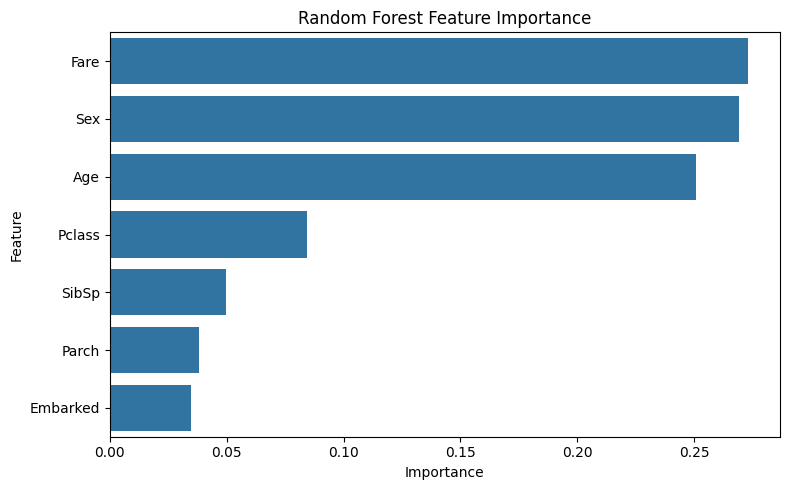

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.show()

In [21]:
print("Linear SVM:", linear_acc)
print("RBF SVM:", rbf_acc)

print(
    "Random Forest:",
    rf_acc
)

print(
    "Bagging:",
    accuracy_score(
        y_test,
        bag_pred
    )
)

print(
    "AdaBoost:",
    accuracy_score(
        y_test,
        boost_pred
    )
)

Linear SVM: 0.7821229050279329
RBF SVM: 0.8156424581005587
Random Forest: 0.8156424581005587
Bagging: 0.8100558659217877
AdaBoost: 0.7988826815642458


# Final Insights

1. SVM models successfully classified passenger survival using Titanic features.

2. The RBF kernel performed differently from the linear kernel because it can capture non-linear relationships.

3. Decision Trees with small depth showed signs of underfitting.

4. Decision Trees with large depth achieved higher training accuracy but risked overfitting.

5. Cross-validation provided a more reliable estimate of model performance than a single train-test split.

6. Bagging and Boosting improved model stability compared to a single Decision Tree.

7. Random Forest produced strong performance by combining multiple decision trees.

8. Feature importance analysis showed which passenger characteristics contributed most to survival prediction.